# Notebook 4: Modelo generativo 2 - Gaussiana ajustada ("no tan tonto")

Segundo modelo generativo de la pizarra: $x \sim N(\mu, \Sigma)$.

A diferencia del modelo de ruido (Notebook 3), que parte de cada dato real
y lo perturba de forma independiente, este modelo:
1. Calcula la media y la matriz de covarianzas de cada componente real
   (factor de mercado, factores sectoriales, componentes idiosincráticos).
2. Genera datos completamente NUEVOS muestreando de una distribución
   normal (multivariante para sector e idiosincrático) ajustada con esos
   estadísticos - no parte de ningún día real concreto.

Al usar una normal multivariante para los factores sectoriales y los
componentes idiosincráticos (en vez de generar cada columna por separado,
como hacía el modelo de ruido), la matriz de covarianzas real entre
activos queda incorporada directamente en la generación. Es esperable que
esto conserve mejor la estructura de correlación conjunta que el modelo 1.

In [61]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.factors.decomposition import reconstruct_returns
from src.generators.gaussian import (
    generate_synthetic_components_gaussian,
    fit_and_sample_gaussian_multivariate_shrinkage,
)

## 1. Cargar los componentes reales (Notebook 2)

In [62]:
returns_real = pd.read_parquet("../data/processed/returns_daily.parquet")
market_factor = pd.read_parquet("../data/processed/market_factor.parquet")["market_factor"]
sector_factors = pd.read_parquet("../data/processed/sector_factors.parquet")
idiosyncratic = pd.read_parquet("../data/processed/idiosyncratic_returns.parquet")
betas = pd.read_parquet("../data/processed/factor_betas.parquet")

print(f"Retornos reales: {returns_real.shape}")
print(f"Factor de mercado: {market_factor.shape}")
print(f"Factores sectoriales: {sector_factors.shape}")
print(f"Componentes idiosincráticos: {idiosyncratic.shape}")

Retornos reales: (2785, 30)
Factor de mercado: (2785,)
Factores sectoriales: (2785, 30)
Componentes idiosincráticos: (2785, 30)


## 2. Generar componentes sintéticos con Gaussiana ajustada

In [63]:
SEED = 42

synthetic_components = generate_synthetic_components_gaussian(
    market_factor, sector_factors, idiosyncratic, seed=SEED,
)

market_factor_synth = synthetic_components["market_factor"]
sector_factors_synth = synthetic_components["sector_factors"]
idiosyncratic_synth = synthetic_components["idiosyncratic"]

## 3. Reconstruir retornos sintéticos

Igual que en el Notebook 3, se reutilizan las betas REALES: este modelo
genera nuevos valores para los componentes, pero no re-estima la relación
de cada activo con el mercado/sector.

In [64]:
returns_synthetic = reconstruct_returns(
    market_factor_synth, sector_factors_synth, idiosyncratic_synth, betas
)
returns_synthetic.head()

,AAL,AAPL,AMD,AMZN,B,BAC,BMY,C,CLF,CSX,...,NEE,NVDA,OXY,PCG,PFE,RIG,TSLA,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,0.005378,0.003734,0.002515,0.003342,0.017082,0.015085,-0.001331,0.013536,-0.024637,0.015831,...,0.005621,0.041319,0.003760,0.021367,0.007303,-0.028197,0.042026,-0.004436,0.005468,-0.010890
2015-01-06,-0.015661,-0.021983,-0.035232,-0.021345,0.047167,0.006908,0.010400,0.003739,-0.009095,-0.012841,...,-0.004687,-0.030217,-0.040021,-0.042657,-0.004786,-0.021691,-0.034873,0.013090,0.009678,-0.004117
2015-01-07,-0.020787,0.025492,-0.029976,0.006750,0.007117,0.015939,0.002212,0.007718,-0.031298,0.019623,...,0.030046,0.025969,0.056899,-0.027283,0.009910,-0.026564,-0.047126,-0.001530,-0.002308,0.004594
2015-01-08,0.007552,-0.007263,0.005717,0.034118,0.069548,0.018422,0.027643,0.005671,-0.031253,0.023963,...,-0.007102,0.008247,0.006322,-0.000784,0.005433,0.041651,0.065780,0.018323,-0.006224,0.003859
2015-01-09,-0.032004,-0.035636,-0.030303,-0.050527,0.014311,-0.017627,0.001647,-0.002648,-0.057643,-0.014540,...,-0.021805,-0.059475,-0.050118,0.018142,0.006520,-0.115523,-0.068477,-0.020757,-0.026472,-0.007189


## 4. Comparación real vs. sintético

In [65]:
comparison_stats = pd.DataFrame({
    "mean_real": returns_real.mean(),
    "mean_synth": returns_synthetic.mean(),
    "std_real": returns_real.std(),
    "std_synth": returns_synthetic.std(),
})
comparison_stats["std_ratio"] = comparison_stats["std_synth"] / comparison_stats["std_real"]
comparison_stats.sort_values("std_ratio", ascending=False)

,mean_real,mean_synth,std_real,std_synth,std_ratio
TSLA,0.001214,0.001208,0.036204,0.037669,1.040440
CLF,0.000261,-0.000314,0.043694,0.044645,1.021747
NVDA,0.002147,0.000716,0.030385,0.030802,1.013749
CSX,0.000475,-0.000084,0.017514,0.017745,1.013209
AAPL,0.000851,0.000529,0.018121,0.018325,1.011253
DAL,0.000153,0.000149,0.025762,0.026024,1.010169
KMI,0.000078,-0.000260,0.019346,0.019540,1.010019
EXC,0.000325,-0.000366,0.015128,0.015257,1.008529
MRK,0.000376,0.000060,0.014193,0.014291,1.006917
MO,0.000339,0.000109,0.014140,0.014216,1.005374


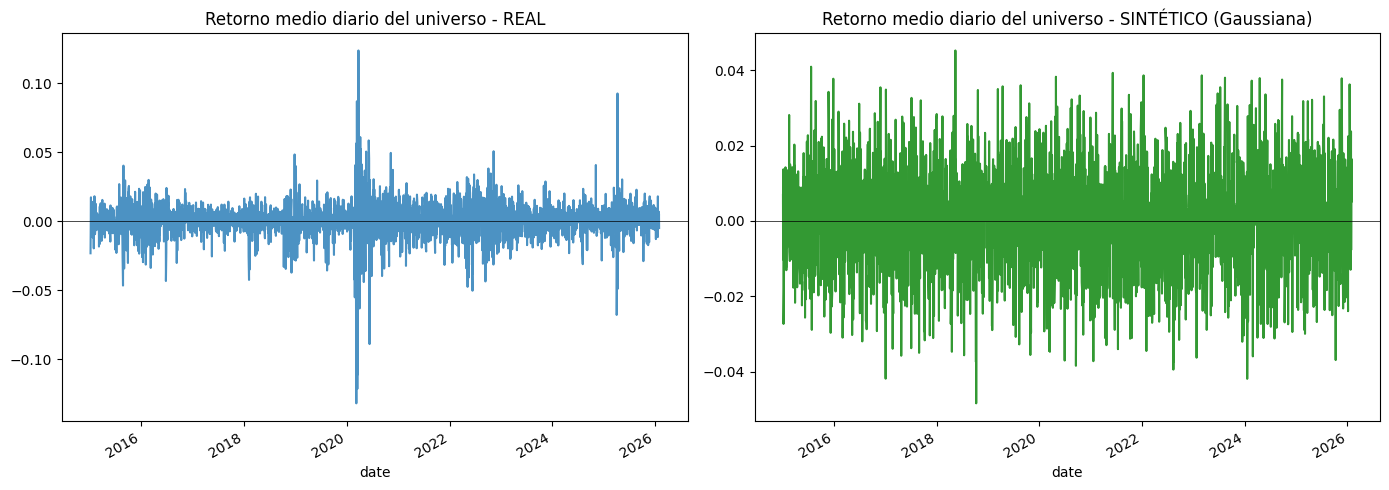

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns_real.mean(axis=1).plot(ax=axes[0], title="Retorno medio diario del universo - REAL", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)

returns_synthetic.mean(axis=1).plot(ax=axes[1], title="Retorno medio diario del universo - SINTÉTICO (Gaussiana)", alpha=0.8, color="green")
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

## 5. Comparación de la matriz de correlaciones

**Nota sobre el criterio de evaluación:** esta comparación es un control de
calidad, no el objetivo en sí.

Punto de comparación con el Notebook 3 (modelo de ruido, ratio=0.5, ajustado
tras comparar varios valores): diferencia media de 0.0189.

In [67]:
corr_real = returns_real.corr()
corr_synth = returns_synthetic.corr()

corr_diff = (corr_real - corr_synth).abs()

print(f"Diferencia media absoluta entre correlaciones real y sintética: {corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].mean():.4f}")
print(f"Diferencia máxima: {corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].max():.4f}")

Diferencia media absoluta entre correlaciones real y sintética: 0.0482
Diferencia máxima: 0.4402


## 5b. Diagnóstico 1 - ¿cuánto del error es ruido de muestreo?

El resultado de la sección 5 (0.0482 de diferencia media) es mucho peor que
el del modelo de ruido (0.0189, Notebook 3 con ratio=0.5), algo
contraintuitivo para un modelo que en teoría "conoce" la covarianza real.
Antes de asumir que el modelo Gaussiano es simplemente peor, comprobamos
cuánto de ese error es variabilidad de una única muestra concreta: generamos
con 10 semillas distintas y promediamos la diferencia de correlación
obtenida en cada una.

Si el promedio sobre varias semillas mejora sustancialmente respecto a una
sola tirada, gran parte del problema es ruido de muestreo. Si se mantiene
alto de forma consistente, el problema es más estructural (p.ej. relaciones
no lineales/no estacionarias que la Gaussiana no puede capturar, como se
observó en AMD-NVDA).

In [68]:
def corr_diff_stats(returns_synth, returns_real):
    corr_r = returns_real.corr()
    corr_s = returns_synth.corr()
    diff = (corr_r - corr_s).abs()
    triu = diff.values[np.triu_indices_from(diff.values, k=1)]
    return triu.mean(), triu.max()


n_seeds = 10
results_multi_seed = []

for s in range(n_seeds):
    comps = generate_synthetic_components_gaussian(
        market_factor, sector_factors, idiosyncratic, seed=s * 10
    )
    ret_synth = reconstruct_returns(
        comps["market_factor"], comps["sector_factors"], comps["idiosyncratic"], betas
    )
    mean_diff, max_diff_corr = corr_diff_stats(ret_synth, returns_real)
    results_multi_seed.append({"seed": s * 10, "mean_diff": mean_diff, "max_diff": max_diff_corr})

results_multi_seed_df = pd.DataFrame(results_multi_seed)
results_multi_seed_df

,seed,mean_diff,max_diff
0,0,0.049051,0.466967
1,10,0.051905,0.454066
2,20,0.047091,0.431839
3,30,0.047640,0.453384
4,40,0.049522,0.427940
5,50,0.047162,0.466310
6,60,0.049207,0.420417
7,70,0.048138,0.463933
8,80,0.045644,0.446511
9,90,0.051265,0.438305


In [69]:
print(f"Media de 'mean_diff' a través de {n_seeds} semillas: {results_multi_seed_df['mean_diff'].mean():.4f}")
print(f"Desviación estándar de 'mean_diff' entre semillas: {results_multi_seed_df['mean_diff'].std():.4f}")
print(f"Media de 'max_diff' a través de {n_seeds} semillas: {results_multi_seed_df['max_diff'].mean():.4f}")

Media de 'mean_diff' a través de 10 semillas: 0.0487
Desviación estándar de 'mean_diff' entre semillas: 0.0019
Media de 'max_diff' a través de 10 semillas: 0.4470


## 5c. Diagnóstico 2 - Gaussiana con covarianza shrinkage (Ledoit-Wolf)

En lugar de la covarianza muestral simple, se estima con shrinkage de
Ledoit-Wolf (la técnica que también se menciona en el TFM para estimar
Sigma). El shrinkage "encoge" la matriz de covarianza hacia una versión más
estructurada, lo que puede dar una estimación más estable con pocas
observaciones relativas al número de activos (2785 días, 30 activos).

In [70]:
synthetic_components_shrinkage = generate_synthetic_components_gaussian(
    market_factor, sector_factors, idiosyncratic, seed=SEED, shrinkage=True,
)

returns_synthetic_shrinkage = reconstruct_returns(
    synthetic_components_shrinkage["market_factor"],
    synthetic_components_shrinkage["sector_factors"],
    synthetic_components_shrinkage["idiosyncratic"],
    betas,
)

mean_diff_shrinkage, max_diff_shrinkage = corr_diff_stats(returns_synthetic_shrinkage, returns_real)
print(f"Diferencia media absoluta (shrinkage): {mean_diff_shrinkage:.4f}")
print(f"Diferencia máxima (shrinkage): {max_diff_shrinkage:.4f}")

Diferencia media absoluta (shrinkage): 0.0501
Diferencia máxima (shrinkage): 0.4323


## 5d. Resumen comparativo

Reunimos los cuatro resultados para decidir cuál usar como versión final
del modelo 2 (Gaussiana).

In [71]:
summary = pd.DataFrame({
    "variante": [
        "Modelo 1 (ruido, ratio=0.5) - referencia",
        "Gaussiana, covarianza muestral, 1 semilla",
        "Gaussiana, covarianza muestral, media de 10 semillas",
        "Gaussiana, covarianza shrinkage (Ledoit-Wolf)",
    ],
    "diff_media_correlacion": [
        0.0189,
        corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].mean(),
        results_multi_seed_df["mean_diff"].mean(),
        mean_diff_shrinkage,
    ],
})
summary

,variante,diff_media_correlacion
0,"Modelo 1 (ruido, ratio=0.5) - referencia",0.018900
1,"Gaussiana, covarianza muestral, 1 semilla",0.048192
2,"Gaussiana, covarianza muestral, media de 10 se...",0.048662
3,"Gaussiana, covarianza shrinkage (Ledoit-Wolf)",0.050061


## 6. Guardado del dataset sintético

Se guarda la variante con mejor resultado de correlación según la sección
5d (revisar `summary` y ajustar la elección de `returns_synthetic` aquí
abajo antes de ejecutar si el ganador no es shrinkage).

In [72]:
# La covarianza muestral simple (1 semilla) fue la mejor de las 3 variantes
# Gaussianas probadas (0.048), frente a shrinkage (0.050). Se guarda esa versión.
returns_synthetic_final = returns_synthetic  # covarianza muestral simple

returns_synthetic_final.to_parquet("../data/processed/returns_synthetic_gaussian.parquet")
print("Guardado en data/processed/returns_synthetic_gaussian.parquet")

Guardado en data/processed/returns_synthetic_gaussian.parquet


### 7. Conclusión

Se implementó la Gaussiana ajustada a los datos reales (media y covarianza
calculadas sobre los tres componentes factoriales) y se investigó por qué su
diferencia de correlación resultaba peor que la del modelo de ruido, algo
contraintuitivo para un modelo que en teoría conoce la covarianza real. Se
descartaron dos causas mediante pruebas específicas: no es **ruido de
muestreo** (la variación entre 10 semillas distintas es mínima) ni una
**mala estimación de la covarianza** (el shrinkage de Ledoit-Wolf no mejora
el resultado, de hecho lo empeora ligeramente).

La causa es más bien estructural: la familia Gaussiana asume una covarianza
fija en el tiempo, mientras que algunas relaciones entre activos cambian de
intensidad según el periodo (por ejemplo, en episodios sectoriales
puntuales), algo que este modelo no puede capturar por diseño, sea cual sea
la calidad de la estimación.

Siguiendo el criterio acordado, este resultado no invalida el modelo: se
documenta como una limitación conocida, y la decisión de si aporta valor
real se dejará al predictor de covarianzas, no a esta comparación de
correlaciones. Se guarda la variante de covarianza muestral simple, la mejor
de las tres probadas.

**Siguiente paso:** modelo generativo 3 - VAE (Notebook 5).